In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set_theme()

In [6]:
data = {
    "delay": pd.read_csv("analysis/aug-2026-labmeeting-summary/data_delay.csv"),
    "budget": pd.read_csv("analysis/aug-2026-labmeeting-summary/data_budget.csv"),
    "curves": pd.read_csv("analysis/aug-2026-labmeeting-summary/curves.csv"),
    "noise": pd.read_csv("analysis/aug-2026-labmeeting-summary/data_noise.csv"),
    "groups": pd.read_csv("analysis/aug-2026-labmeeting-summary/data_probe_groups.csv"),
}
def held_out(frame: pd.DataFrame) -> pd.DataFrame:
    return frame[(frame["dataset"] == "old_eval") & frame["have_eval"]]

In [29]:
df.condition.unique()

array(['efference_old', 'encdec', 'expfm', 'expfm_2g', 'no_efference_old',
       'pgfm', 'pgfm_2g'], dtype=object)

/tmp/ipykernel_8334/1095223363.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.311' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df.delay_k==0, "delay_k"] = 0.311 #Cosmetic, for log x-axis


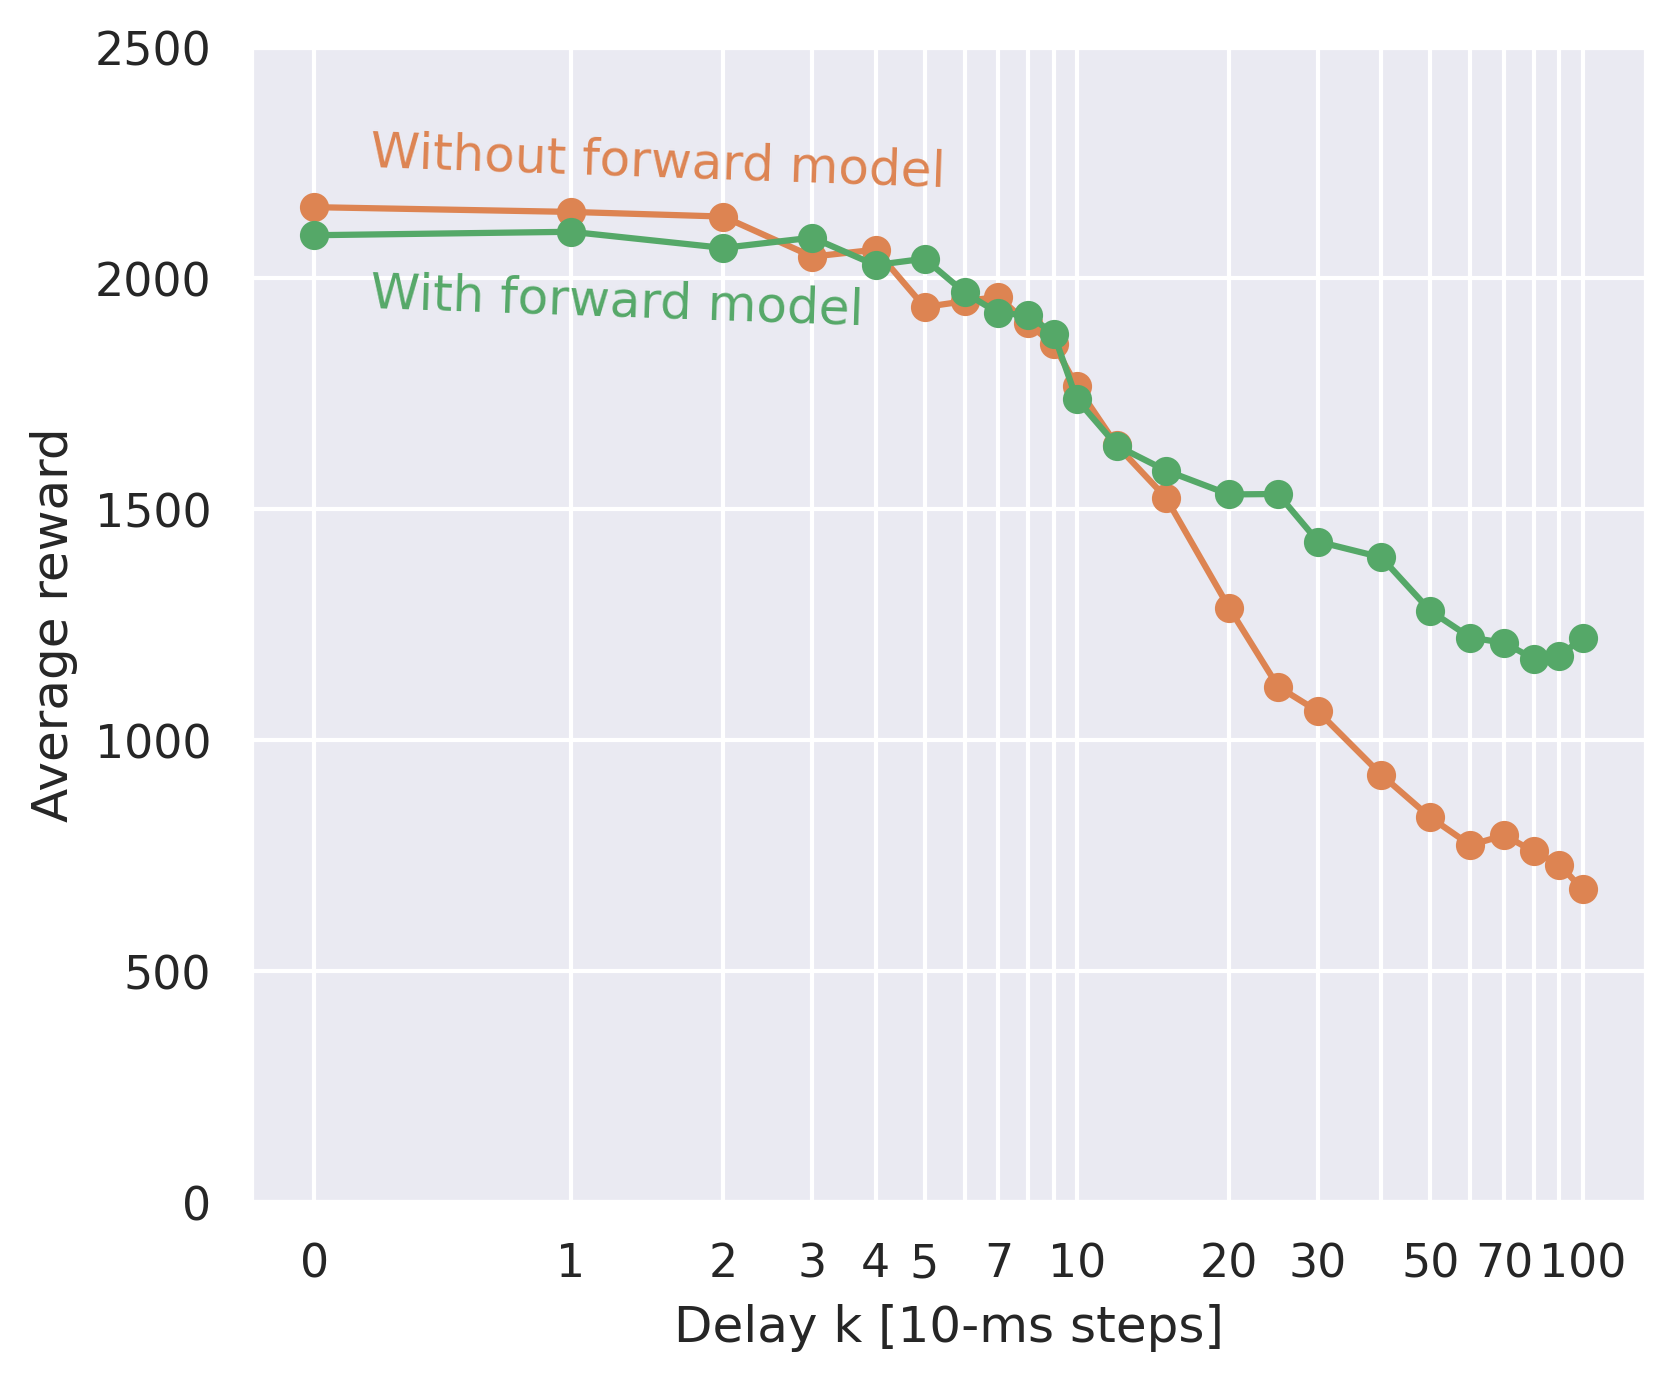

In [44]:
plt.figure(dpi=300, figsize=(6, 5))
df = held_out(data["delay"])
df.loc[df.delay_k==0, "delay_k"] = 0.311 #Cosmetic, for log x-axis

d = df[df.condition=="encdec"].groupby("delay_k").episode_reward.mean()
plt.plot(d.index, d, '-o', color="C1")

d = df[df.condition=="expfm"].groupby("delay_k").episode_reward.mean()
plt.plot(d.index, d, '-o', color="C2")

plt.gca().set_xscale("log")
plt.ylim(0, 2500)
plt.xlabel("Delay k [10-ms steps]")
plt.ylabel("Average reward")
xticks = [0.311, 1,2,3,4,5,6,7,8,9,10,20,30,40,50,60,70,80,90,100]
xticklabels = [0, 1,2,3,4,5,"",7,"","",10,20,30,"",50,"",70,"","",100]
plt.xticks(xticks, xticklabels)
plt.text(0.4, 2200, "Without forward model", color="C1", rotation=-2)
plt.text(0.4, 1900, "With forward model", color="C2", rotation=-2)
plt.show()

/tmp/ipykernel_8334/3821869275.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.311' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df.delay_k==0, "delay_k"] = 0.311 #Cosmetic, for log x-axis


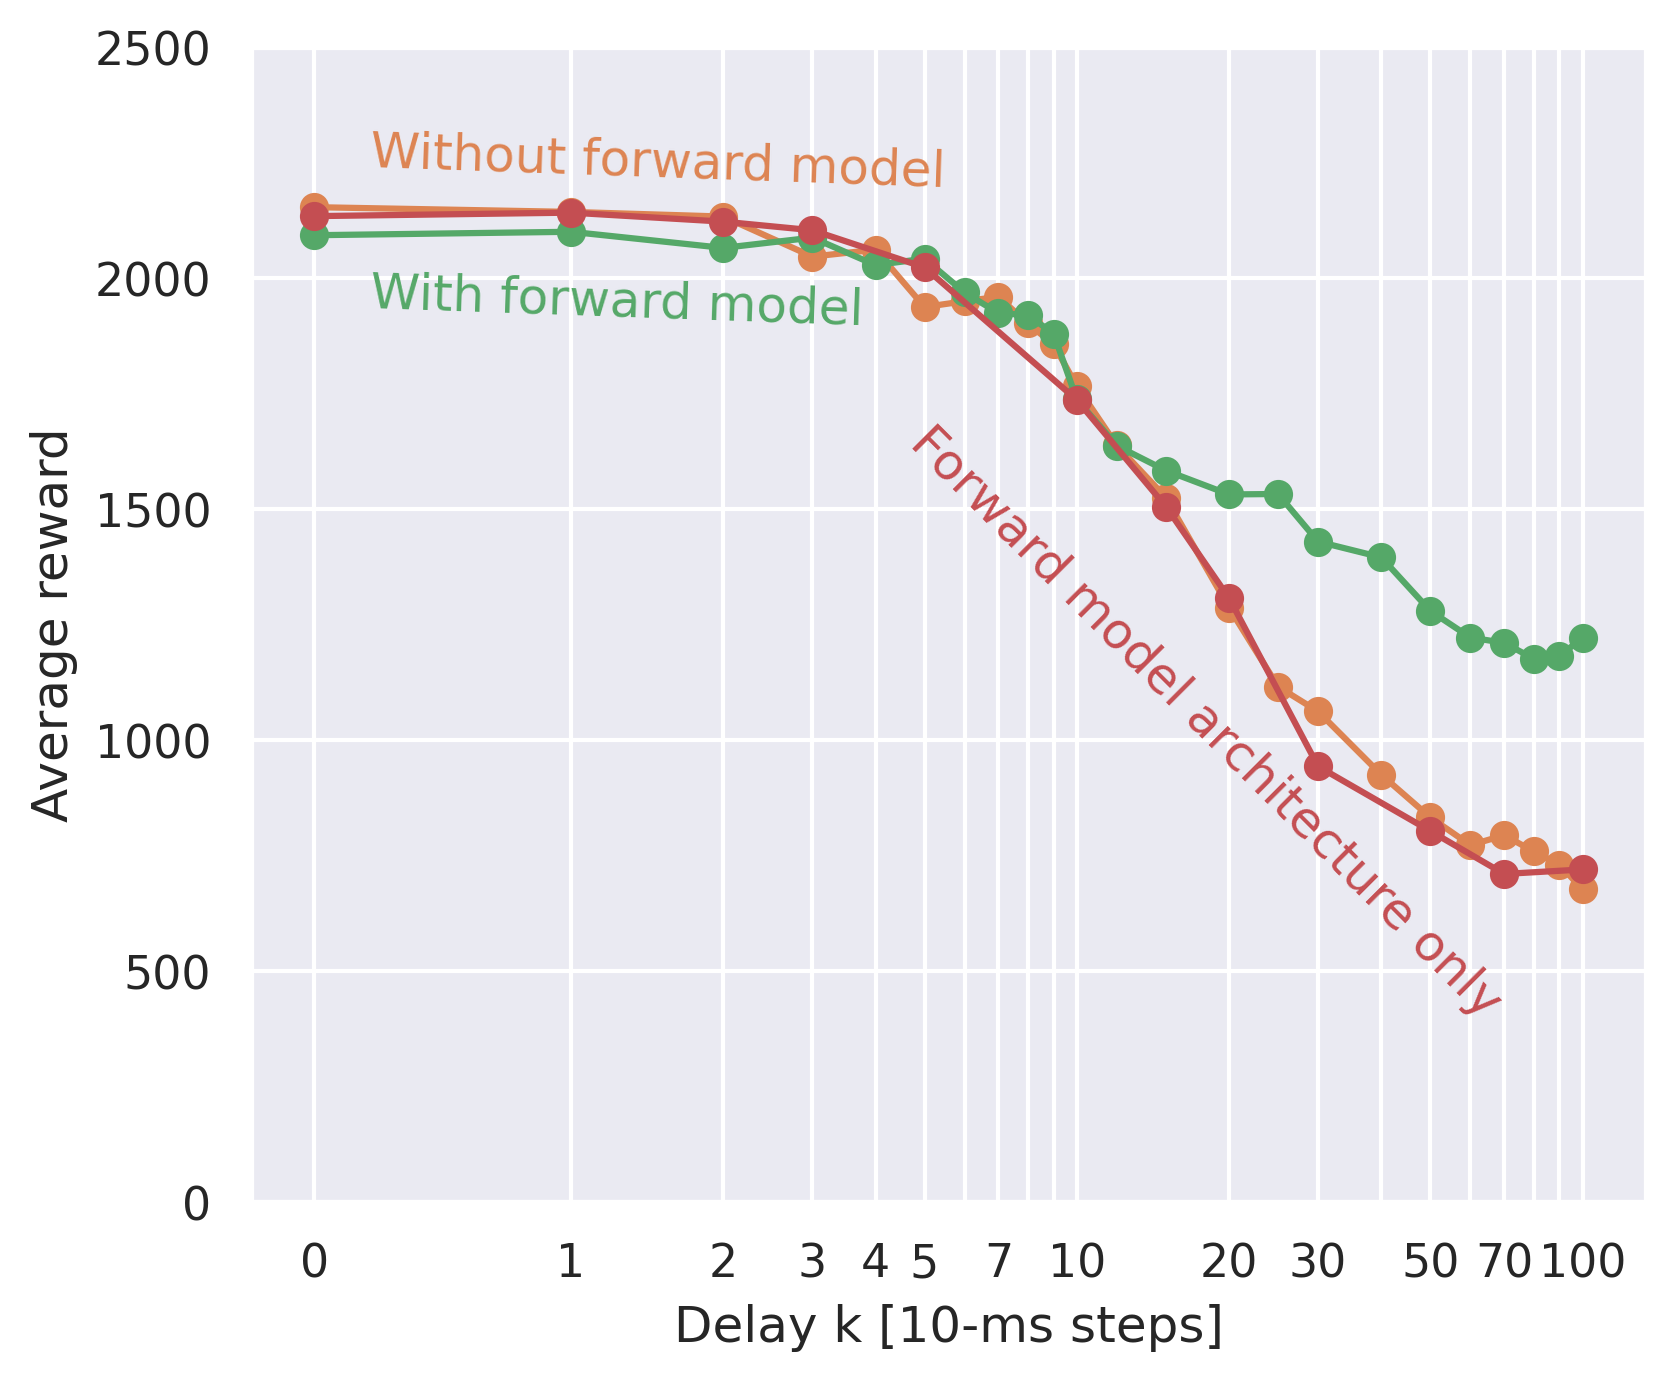

In [50]:
plt.figure(dpi=300, figsize=(6, 5))
df = held_out(data["delay"])
df.loc[df.delay_k==0, "delay_k"] = 0.311 #Cosmetic, for log x-axis

d = df[df.condition=="encdec"].groupby("delay_k").episode_reward.mean()
plt.plot(d.index, d, '-o', color="C1")

d = df[df.condition=="expfm"].groupby("delay_k").episode_reward.mean()
plt.plot(d.index, d, '-o', color="C2")

d = df[df.condition=="pgfm"].groupby("delay_k").episode_reward.mean()
plt.plot(d.index, d, '-o', color="C3")

plt.gca().set_xscale("log")
plt.ylim(0, 2500)
plt.xlabel("Delay k [10-ms steps]")
plt.ylabel("Average reward")
xticks = [0.311, 1,2,3,4,5,6,7,8,9,10,20,30,40,50,60,70,80,90,100]
xticklabels = [0, 1,2,3,4,5,"",7,"","",10,20,30,"",50,"",70,"","",100]
plt.xticks(xticks, xticklabels)
plt.text(0.4, 2200, "Without forward model", color="C1", rotation=-2)
plt.text(0.4, 1900, "With forward model", color="C2", rotation=-2)
plt.text(4.5, 400, "Forward model architecture only", color="C3", rotation=-45)
plt.show()

In [57]:
df.condition.unique()

array(['expfm', 'expfm_2g', 'pgfm', 'pgfm_2g'], dtype=object)

Text(700000000.0, 200, 'Default budget (600M)')

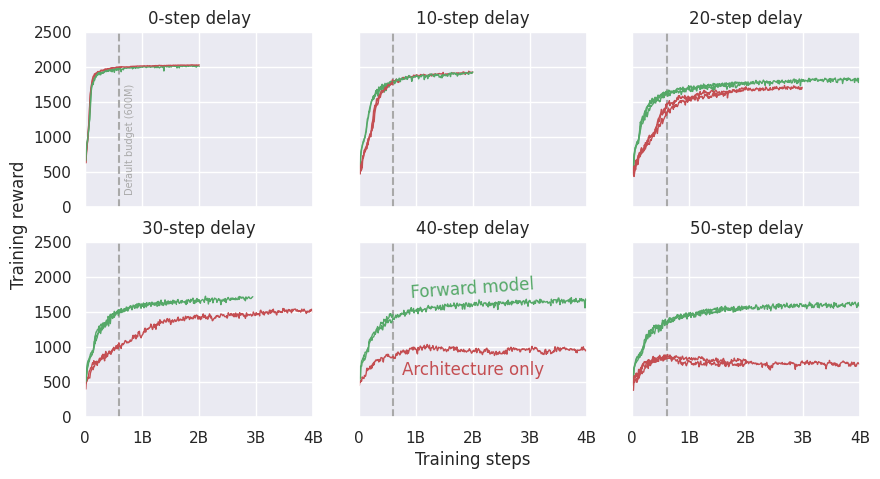

In [118]:
fig, axs = plt.subplots(2, 3, figsize=(10, 5), sharex="col", sharey=True)
for ax, delay in zip(axs.flat, (0,10,20,30,40,50)):
    plt.sca(ax)
    df = data["curves"].query(f"delay_k == {delay}")
    plt.axvline(6e8, color="darkgray", ls="--")
    for _, g in df.groupby("wandb_id"):
        if g.condition.iloc[0].startswith("expfm"):
            c = "C2"
        elif g.condition.iloc[0].startswith("pgfm"):
            c = "C3"
        else:
            raise "Unknown condition:" + str(g.condition.iloc[0])
        plt.plot(g.step, g.reward_mean, color=c, lw=1, alpha=1)
    plt.xlim(0, 4e9)
    plt.ylim(0, 2500)
    plt.title(f"{delay}-step delay")
    plt.xticks((0, 1e9, 2e9, 3e9, 4e9), ("0", "1B", "2B", "3B", "4B"))
    
axs[1,1].set_xlabel("Training steps")
axs[0,0].set_ylabel("Training reward", y=-0.1)
axs[1,1].text(2e9, 1700, "Forward model", color="C2", ha="center", rotation=4)
axs[1,1].text(2e9, 600, "Architecture only", color="C3", ha="center", rotation=0)
axs[0,0].text(7e8, 200, "Default budget (600M)", color="darkgray", rotation=90, fontsize=7)

In [292]:
df = data["budget"]
collection = []
collection.append(df[df.max_step > 4e9][["delay_k", "condition", "max_step", "reward_at_4G"]].rename(columns={"reward_at_4G": "reward"}))
collection.append(df[(df.max_step < 4e9) & (df.max_step > 2.9e9)][["delay_k","condition", "max_step", "reward_at_2p9G"]].rename(columns={"reward_at_2p9G": "reward"}))
collection.append(df[(df.max_step < 2.9e9) & (df.max_step > 2e9)][["delay_k","condition", "max_step", "reward_at_2G"]].rename(columns={"reward_at_2G": "reward"}))
extra_df = pd.concat(collection)
extra_df["condition"] = df.condition.str[:4]

/tmp/ipykernel_8334/1672508141.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.311' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  d.loc[d.delay_k==0, "delay_k"] = 0.311 #Cosmetic, for log x-axis
/tmp/ipykernel_8334/1672508141.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.311' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  d.loc[d.delay_k==0, "delay_k"] = 0.311 #Cosmetic, for log x-axis
/tmp/ipykernel_8334/1672508141.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.311' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  d.loc[d.delay_k==0, "delay_k"] = 0.311 #Cosmetic, for log x-axis
/tmp/ipykernel_833

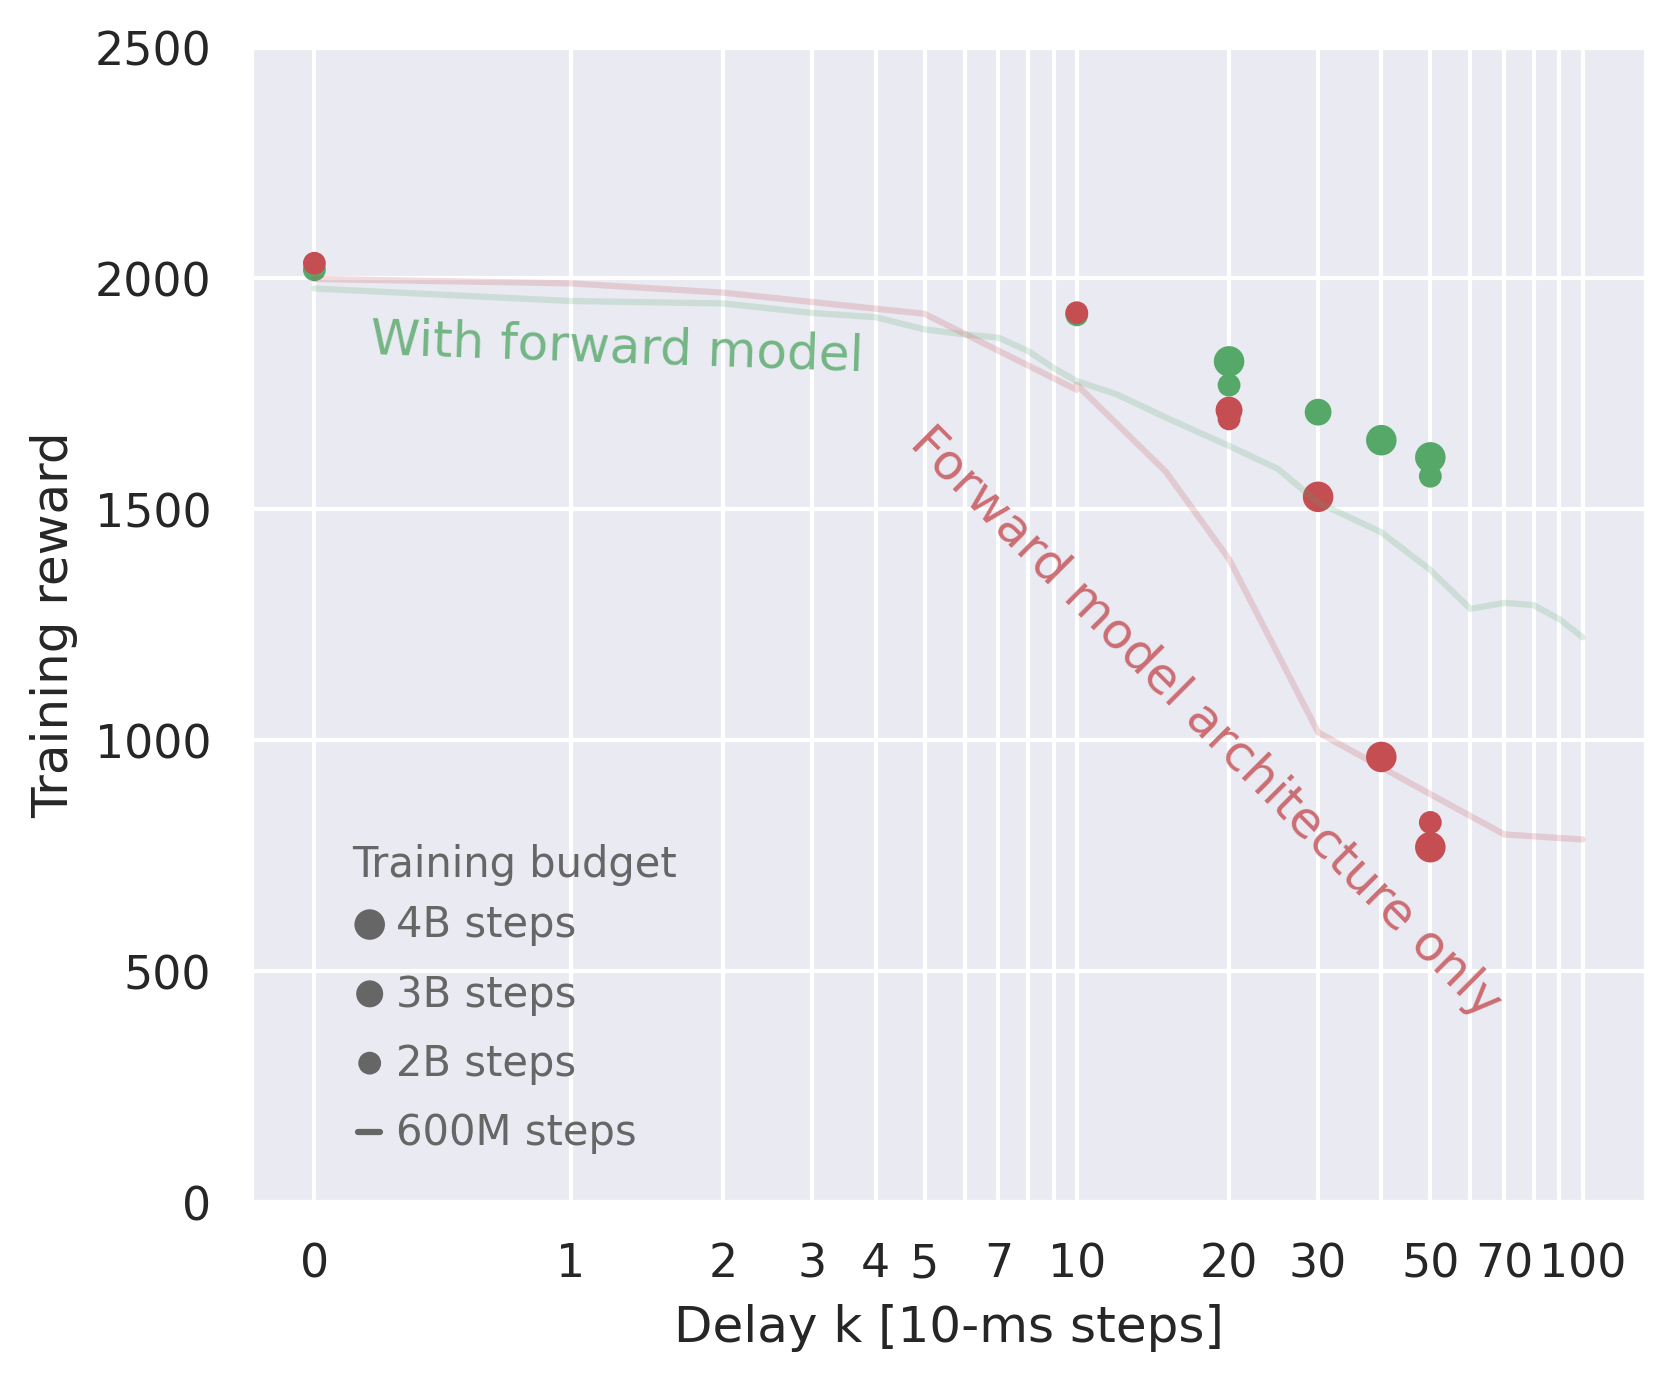

In [293]:
plt.figure(dpi=300, figsize=(6, 5))
d = df[(df.max_step==600064000) & (df.condition=="expfm")]
d.loc[d.delay_k==0, "delay_k"] = 0.311 #Cosmetic, for log x-axis
plt.semilogx(d.delay_k, d.reward_at_600M, '-', color="C2", alpha=0.2)

d = df[(df.max_step==600064000) & (df.condition=="pgfm")]
d.loc[d.delay_k==0, "delay_k"] = 0.311 #Cosmetic, for log x-axis
plt.semilogx(d.delay_k, d.reward_at_600M, '-', color="C3", alpha=0.2)

d = extra_df[(extra_df.condition=="expf")]
d.loc[d.delay_k==0, "delay_k"] = 0.311 #Cosmetic, for log x-axis
plt.scatter(d.delay_k, d.reward, s=d.max_step/1e8, color="C2")

d = extra_df[(extra_df.condition=="pgfm")]
d.loc[d.delay_k==0, "delay_k"] = 0.311 #Cosmetic, for log x-axis
plt.scatter(d.delay_k, d.reward, s=d.max_step/1e8, color="C3")

plt.scatter([0.4]*3, [300, 450, 600], s=[20,30,40], color="0.4")
plt.plot([0.38,0.42], [150, 150], color="0.4")
plt.text(0.45, 150, "600M steps", color="0.4", va="center", fontsize=10)
plt.text(0.45, 300, "2B steps", color="0.4", va="center", fontsize=10)
plt.text(0.45, 450, "3B steps", color="0.4", va="center", fontsize=10)
plt.text(0.45, 600, "4B steps", color="0.4", va="center", fontsize=10)
plt.text(0.37, 730, "Training budget", color="0.4", va="center", fontsize=10)
#edgecolor='k', color="None")

plt.ylim(0, 2500)
plt.xlabel("Delay k [10-ms steps]")
plt.ylabel("Training reward")
xticks = [0.311, 1,2,3,4,5,6,7,8,9,10,20,30,40,50,60,70,80,90,100]
xticklabels = [0, 1,2,3,4,5,"",7,"","",10,20,30,"",50,"",70,"","",100]
plt.xticks(xticks, xticklabels)
plt.text(0.4, 1800, "With forward model", color="C2", rotation=-2, alpha=0.8)
plt.text(4.5, 400, "Forward model architecture only", color="C3", rotation=-45, alpha=0.8)
plt.show()

In [294]:
df = data["noise"]
df = df[(df["dataset"] == "old_eval") & df["have_eval"]]

/tmp/ipykernel_8334/509185463.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.311' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  d.loc[d.delay_k==0, "delay_k"] = 0.311 #Cosmetic, for log x-axis
/tmp/ipykernel_8334/509185463.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.311' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  d.loc[d.delay_k==0, "delay_k"] = 0.311 #Cosmetic, for log x-axis
/tmp/ipykernel_8334/509185463.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.311' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  d.loc[d.delay_k==0, "delay_k"] = 0.311 #Cosmetic, for log x-axis
/tmp/ipykernel_8334/

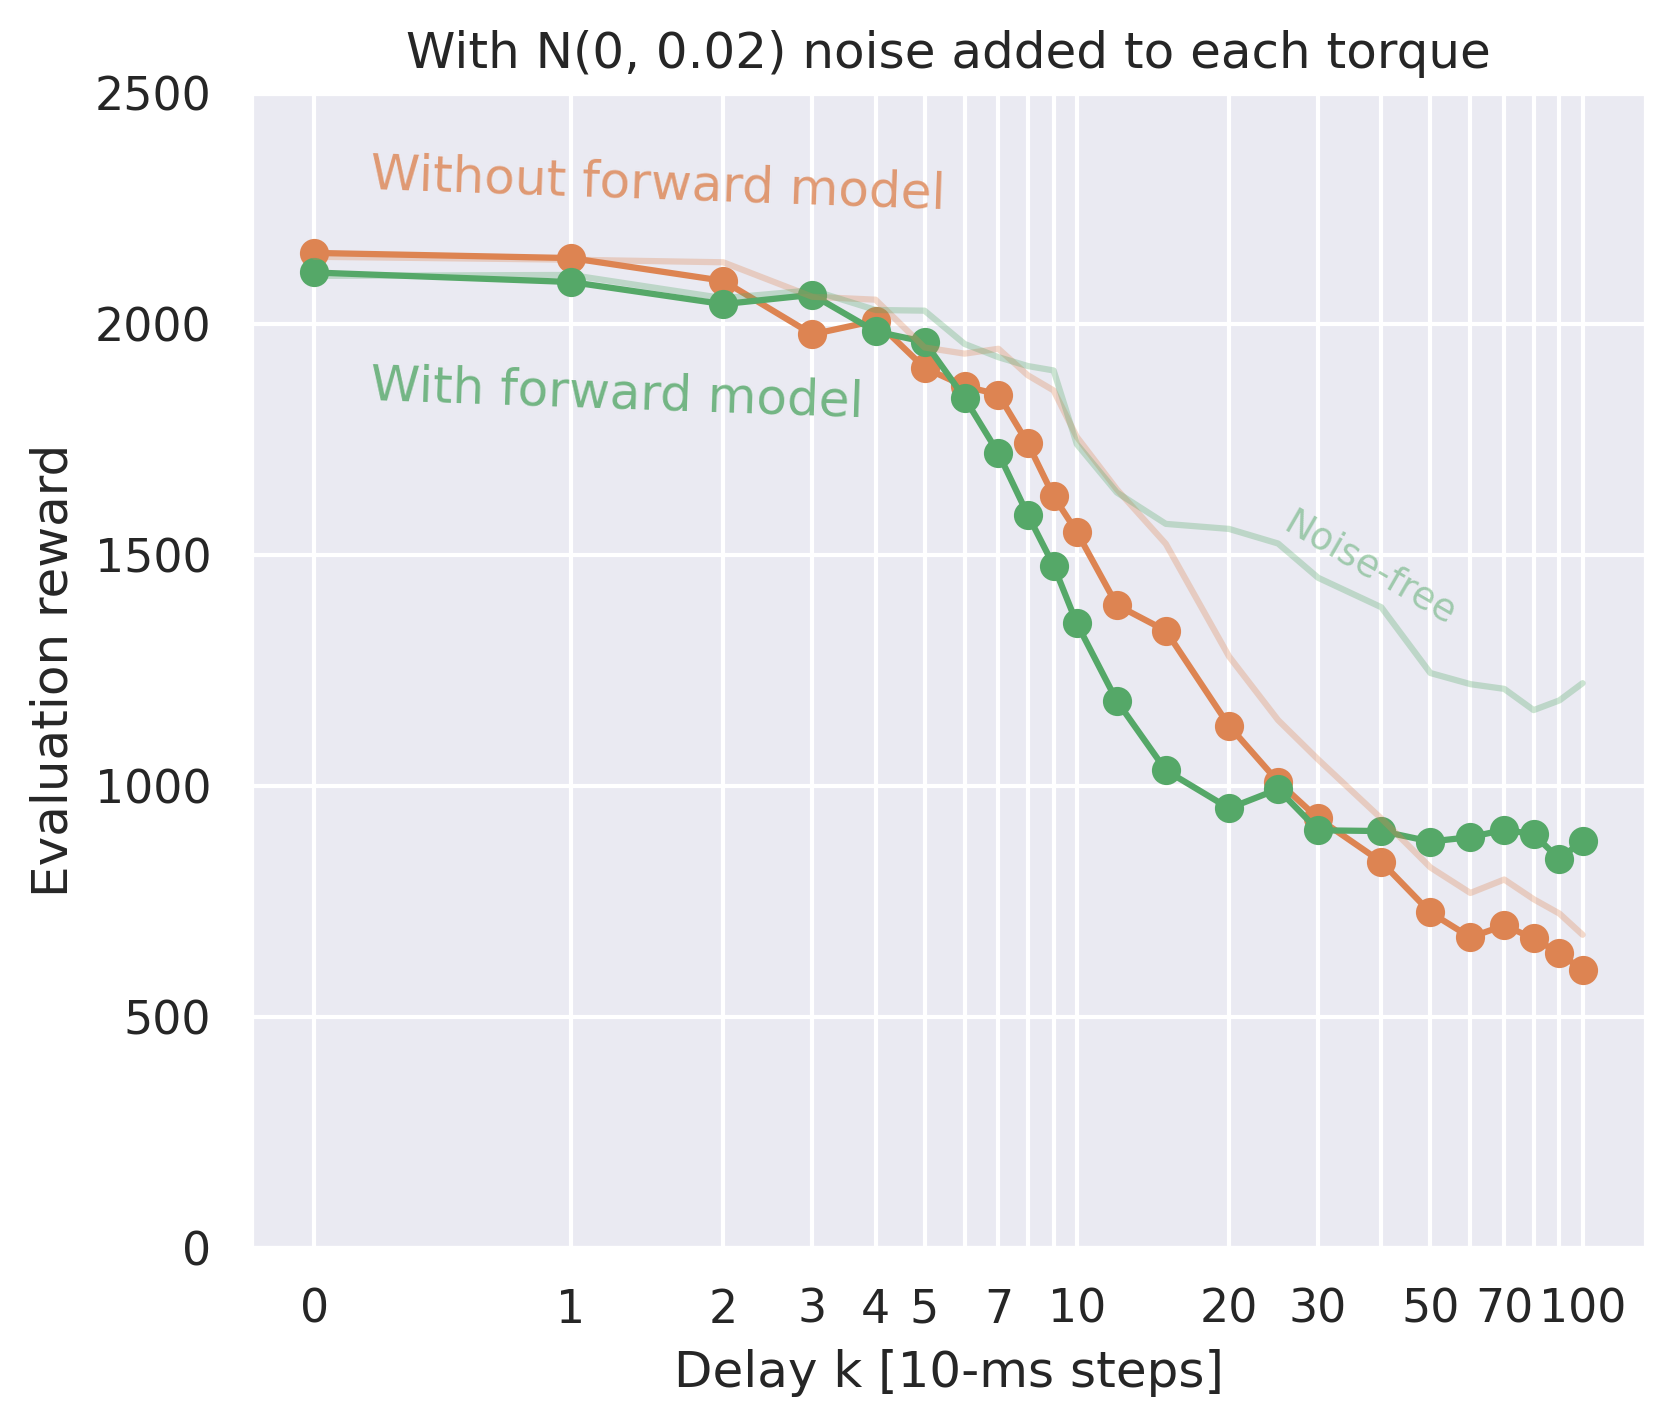

In [295]:
plt.figure(dpi=300, figsize=(6, 5))
d = df[(df.action_noise == 0.02) & (df.condition == "encdec")].copy()
d["delay_k"] = d.delay_k.astype(int)
d.loc[d.delay_k==0, "delay_k"] = 0.311 #Cosmetic, for log x-axis
d = d.sort_values("delay_k")
plt.semilogx(d.delay_k, d.episode_reward, '-o', color="C1")

d = df[(df.action_noise == 0.02) & (df.condition == "expfm")].copy()
d["delay_k"] = d.delay_k.astype(int)
d.loc[d.delay_k==0, "delay_k"] = 0.311 #Cosmetic, for log x-axis
d = d.sort_values("delay_k")
plt.semilogx(d.delay_k, d.episode_reward, '-o', color="C2")

d = df[(df.action_noise == 0.00) & (df.condition == "encdec")].copy()
d["delay_k"] = d.delay_k.astype(int)
d.loc[d.delay_k==0, "delay_k"] = 0.311 #Cosmetic, for log x-axis
d = d.sort_values("delay_k")
plt.semilogx(d.delay_k, d.episode_reward, color="C1", alpha=0.3)

d = df[(df.action_noise == 0.00) & (df.condition == "expfm")].copy()
d["delay_k"] = d.delay_k.astype(int)
d.loc[d.delay_k==0, "delay_k"] = 0.311 #Cosmetic, for log x-axis
d = d.sort_values("delay_k")
plt.semilogx(d.delay_k, d.episode_reward, color="C2", alpha=0.3)

plt.ylim(0, 2500)
plt.xlabel("Delay k [10-ms steps]")
plt.ylabel("Evaluation reward")
xticks = [0.311, 1,2,3,4,5,6,7,8,9,10,20,30,40,50,60,70,80,90,100]
xticklabels = [0, 1,2,3,4,5,"",7,"","",10,20,30,"",50,"",70,"","",100]
plt.xticks(xticks, xticklabels)
plt.text(0.4, 1800, "With forward model", color="C2", rotation=-2, alpha=0.8)
plt.text(0.4, 2250, "Without forward model", color="C1", rotation=-2, alpha=0.8)
plt.text(25, 1350, "Noise-free", color="C2", rotation=-30, alpha=0.5, fontsize=9)
plt.title("With N(0, 0.02) noise added to each torque")
plt.show()

Text(0.5, 1.0, '10-step delay')

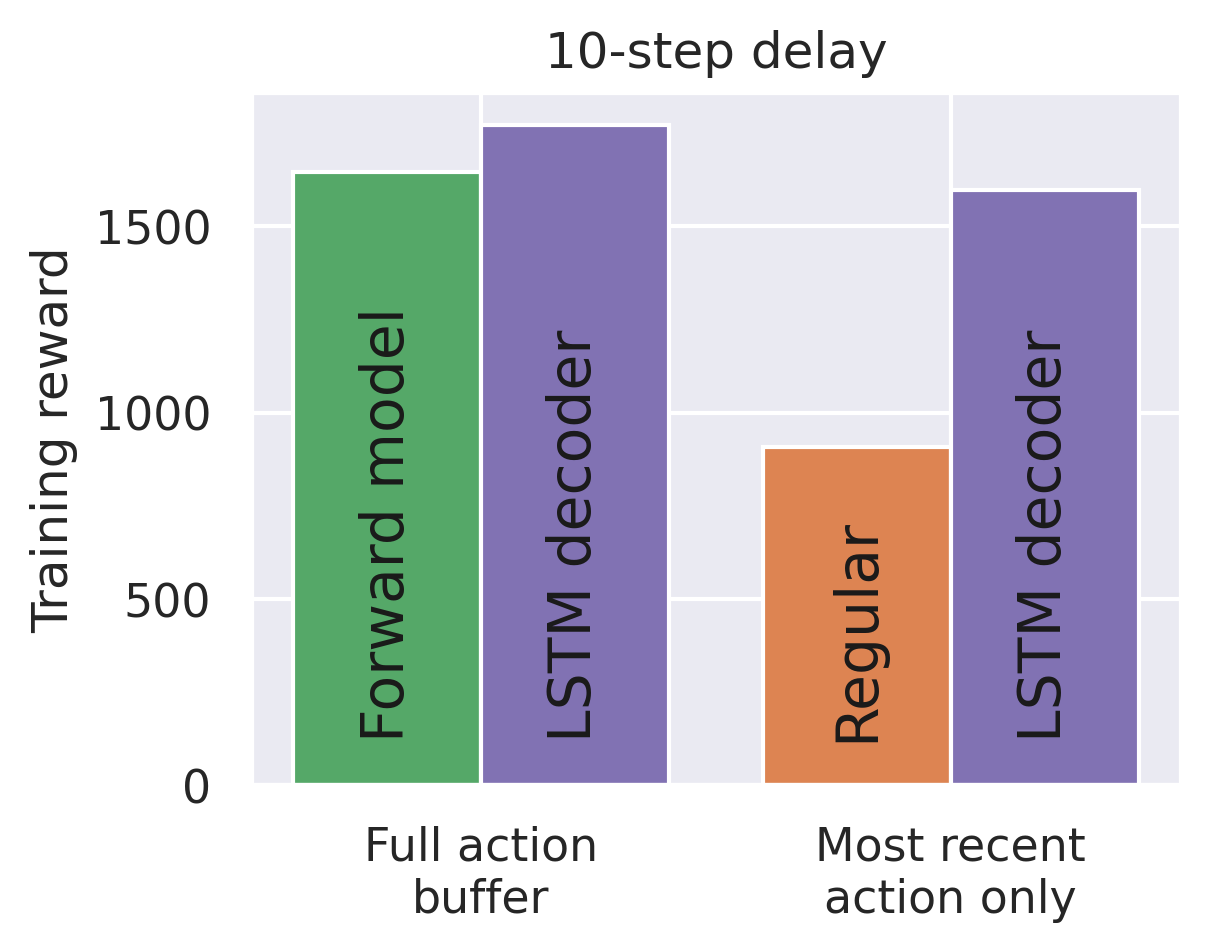

In [296]:
plt.figure(figsize=(4,3), dpi=300)
lstm_data = [
    ("forward_model", 10, 10, 1645.31396),
    ("lstm", 10, 10, 1770.55225),
    ("enc_dec", 10, 1, 906.80981),
    ("lstm", 10, 1, 1598.59937),
]
lstm_data = pd.DataFrame(lstm_data, columns=["model", "delay", "efference", "reward"])
plt.bar([0,1,2.5,3.5], lstm_data.reward, 1.0, color=["C2", "C4", "C1", "C4"])
plt.ylabel("Training reward")
plt.xticks([0.5, 3], ["Full action\nbuffer", "Most recent\naction only"])
plt.text(0, 150, "Forward model", ha="center", rotation=90, color="k", fontsize=14)
plt.text(1, 150, "LSTM decoder", ha="center", rotation=90, color="k", fontsize=14)
plt.text(2.5, 150, "Regular", ha="center", rotation=90, color="k", fontsize=14)
plt.text(3.5, 150, "LSTM decoder", ha="center", rotation=90, color="k", fontsize=14)
plt.title("10-step delay")